# CAP-A Deep Research Agent: Graph Demo

## Objective

Use a notebook to:

- import the scaffolded Cap-A project
- build the LangGraph app
- display the graph structure visually
- run a research request
- inspect the interrupt payload at the review gate


In [79]:
from IPython.display import Image, display

imports `build_app()` from the Cap-A project so the notebook can compile the graph.

In [80]:
import importlib
import graph

importlib.reload(graph)
from graph import build_app

Build the app

In [81]:
app = build_app()

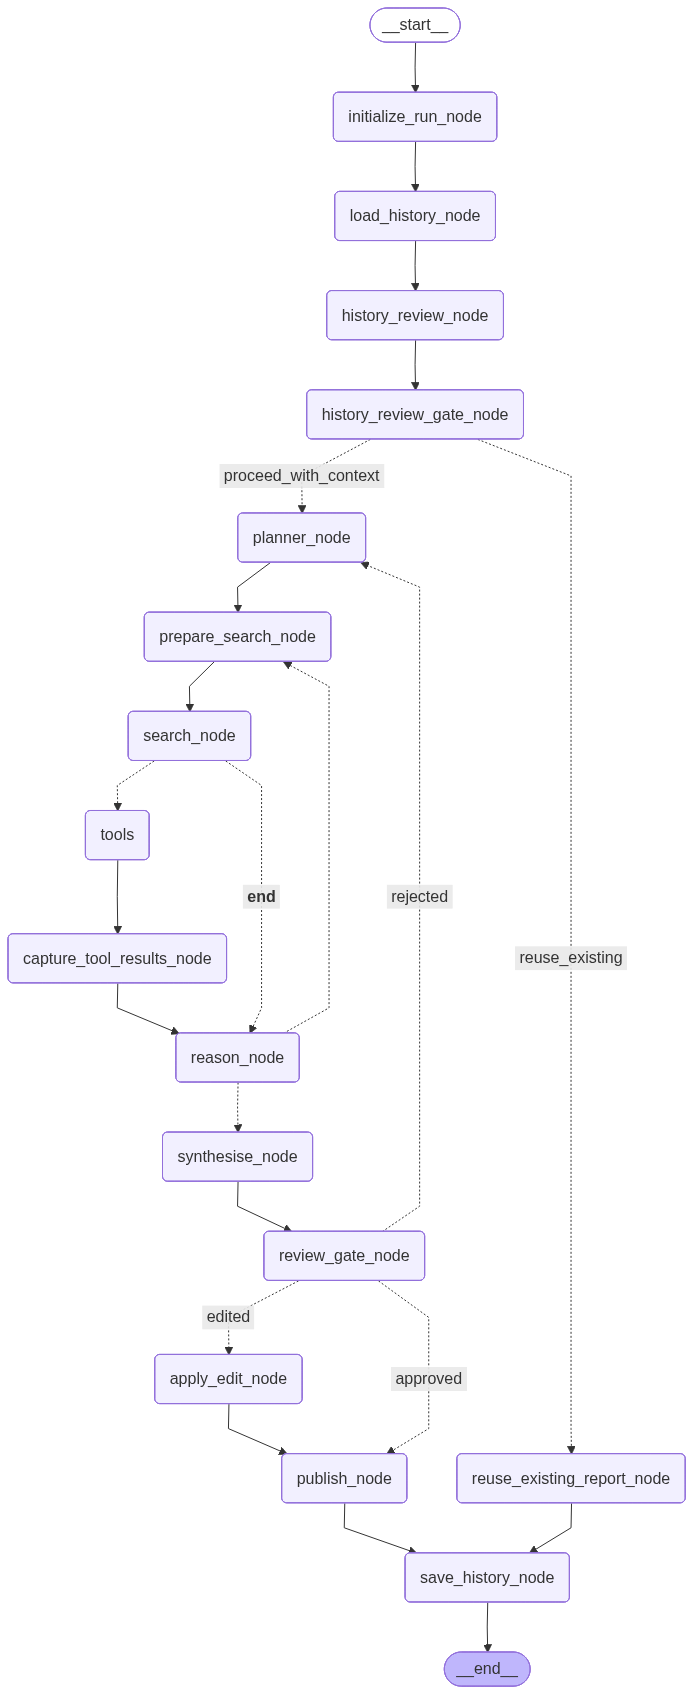

In [82]:
display(Image(app.get_graph().draw_mermaid_png()))

Print the graph as Mermaid text

In [5]:
#print(app.get_graph().draw_mermaid())

## Prepare a research run

### Explanation

This cell defines the runtime config and the initial state for the research agent.

In [99]:
import ipywidgets as widgets
from IPython.display import Markdown, display
from sample_queries import SAMPLE_QUERIES
from uuid import uuid4

run_id = uuid4().hex[:8]

query_options = [
    (f"{item['id']} | {item['domain']} | {item['expected_match_type']}", item["id"])
    for item in SAMPLE_QUERIES
]

query_picker = widgets.Dropdown(
    options=query_options,
    value=SAMPLE_QUERIES[0]["id"],
    description="Query:",
    layout=widgets.Layout(width="700px"),
)

query_preview = widgets.HTML()

def build_initial_state(query_id: str) -> dict:
    selected = next(item for item in SAMPLE_QUERIES if item["id"] == query_id)
    return {
        "question": selected["query"],
        "user_id": "bhupen",
        "max_iterations": 3,
        "messages": [],
    }

def show_query_preview(*_):
    global config, initial_state
    selected = next(item for item in SAMPLE_QUERIES if item["id"] == query_picker.value)
    config = {"configurable": {"thread_id": f"bhupen-{query_picker.value}-{run_id}"}}
    initial_state = build_initial_state(query_picker.value)
    query_preview.value = (
        f"<b>Selected Query</b>: {selected['query']}<br><br>"
        f"<b>Domain</b>: {selected['domain']}<br><br>"
        f"<b>Expected Match Type</b>: {selected['expected_match_type']}<br><br>"
        f"<b>Thread ID</b>: {config['configurable']['thread_id']}<br><br>"
        f"<b>Expected Behavior</b>: {selected['expected_behavior']}"
    )

query_picker.observe(show_query_preview, names="value")
display(query_picker)
display(query_preview)
show_query_preview()

initial_state

Dropdown(description='Query:', layout=Layout(width='700px'), options=(('q01 | AI | new', 'q01'), ('q02 | Physi…

HTML(value='')

{'question': 'What is the impact of transformer architecture on natural language processing?',
 'user_id': 'bhupen',
 'max_iterations': 3,
 'messages': []}

## Start the research run

### Explanation

This cell invokes the graph with the selected research question.

### Expected result

The graph may pause at `history_review_gate_node` if similar prior research exists. Otherwise, it continues until `review_gate_node` and pauses for draft review.

In [100]:
current_state = app.get_state(config)

if current_state.tasks and current_state.tasks[0].interrupts:
    paused_state = current_state
    result = {"status": "already_paused", "next": paused_state.next}
elif current_state.values.get("final_report"):
    paused_state = current_state
    result = current_state.values.get("final_report")
else:
    result = app.invoke(initial_state, config=config)
    paused_state = app.get_state(config)

result

{'question': 'What is the impact of transformer architecture on natural language processing?',
 'user_id': 'bhupen',
 'messages': [],
 'iteration': 0,
 'max_iterations': 3,
 'past_topics': [{'question': 'What is the impact of transformer architecture on natural language processing?',
   'report': {'title': 'Impact of Transformer Architecture on Natural Language Processing',
    'summary': 'Transformers have transformed NLP by enhancing performance across tasks while also posing challenges like resource intensity and interpretability.',
    'key_findings': ['Transformers have revolutionized NLP by significantly improving model performance on various tasks such as translation and sentiment analysis.',
     'Recent advancements include architectures like BERT and GPT, which have set new benchmarks in language understanding.',
     'Transformers face challenges including high computational costs, large model sizes, and issues with interpretability.',
     'Real-world applications range fro

## Optional: handle history match / reuse

If the question matches old saved research, the graph pauses here before doing new research.

Available decisions:

- `reuse_existing`: return the old report directly
- `proceed_with_context`: continue research using old report as context
- `start_fresh_plan`: ignore old report and research from scratch

In [101]:
from IPython.display import JSON, Markdown, display
from langgraph.types import Command

first_pause = paused_state if "paused_state" in globals() else app.get_state(config)
first_payload = (
    first_pause.tasks[0].interrupts[0].value
    if first_pause.tasks and first_pause.tasks[0].interrupts
    else None
)

display(JSON(first_payload) if first_payload else Markdown("No interrupt found."))

if first_payload and first_payload.get("action") == "review_history_match":
    history_decision = widgets.RadioButtons(
        options=[
            ("Reuse existing report", "reuse_existing"),
            ("Continue with prior context", "proceed_with_context"),
            ("Start fresh", "start_fresh_plan"),
        ],
        value="proceed_with_context",
        description="History:",
        layout=widgets.Layout(width="420px"),
    )
    display(history_decision)
else:
    history_decision = None
    display(Markdown("No history reuse decision needed. Continue to draft review."))

<IPython.core.display.JSON object>

RadioButtons(description='History:', index=1, layout=Layout(width='420px'), options=(('Reuse existing report',…

In [102]:
if first_payload and first_payload.get("action") == "review_history_match":
    result = app.invoke(Command(resume=history_decision.value), config=config)
    paused_state = app.get_state(config)
    display(result.get("final_report", result))
else:
    paused_state = first_pause
    display(Markdown("Using the current pause for draft review."))

{}

## Inspect the paused graph state

### Explanation

This cell retrieves the graph state after invocation. If the graph paused correctly, the state should contain an interrupt task.

### Expected result

You should get a state object containing an interrupt entry.

In [103]:
paused_state = app.get_state(config)
display(paused_state)

StateSnapshot(values={'question': 'What is the impact of transformer architecture on natural language processing?', 'user_id': 'bhupen', 'messages': [AIMessage(content='Reused an existing published report from history for the current question.', additional_kwargs={}, response_metadata={}, id='50279b0d-ef0d-4487-b766-8c51b39e59e6', tool_calls=[], invalid_tool_calls=[])], 'iteration': 0, 'max_iterations': 3, 'past_topics': [{'question': 'What is the impact of transformer architecture on natural language processing?', 'report': {'title': 'Impact of Transformer Architecture on Natural Language Processing', 'summary': 'Transformers have transformed NLP by enhancing performance across tasks while also posing challenges like resource intensity and interpretability.', 'key_findings': ['Transformers have revolutionized NLP by significantly improving model performance on various tasks such as translation and sentiment analysis.', 'Recent advancements include architectures like BERT and GPT, whic

In [104]:
print("Next node:", paused_state.next)
print("Values:")
print(paused_state.values)
print("Tasks:")
print(paused_state.tasks)

Next node: ()
Values:
{'question': 'What is the impact of transformer architecture on natural language processing?', 'user_id': 'bhupen', 'messages': [AIMessage(content='Reused an existing published report from history for the current question.', additional_kwargs={}, response_metadata={}, id='50279b0d-ef0d-4487-b766-8c51b39e59e6', tool_calls=[], invalid_tool_calls=[])], 'iteration': 0, 'max_iterations': 3, 'past_topics': [{'question': 'What is the impact of transformer architecture on natural language processing?', 'report': {'title': 'Impact of Transformer Architecture on Natural Language Processing', 'summary': 'Transformers have transformed NLP by enhancing performance across tasks while also posing challenges like resource intensity and interpretability.', 'key_findings': ['Transformers have revolutionized NLP by significantly improving model performance on various tasks such as translation and sentiment analysis.', 'Recent advancements include architectures like BERT and GPT, whi

In [105]:
print("Next node:", paused_state.next)
print("Available state keys:", list(paused_state.values.keys()))
print("Interrupt count:", len(paused_state.tasks[0].interrupts) if paused_state.tasks else 0)

Next node: ()
Available state keys: ['question', 'user_id', 'messages', 'iteration', 'max_iterations', 'past_topics', 'history_review', 'history_decision', 'search_results', 'review_decision', 'human_feedback', 'final_report']
Interrupt count: 0


In [106]:
from pprint import pprint

print("Next node:")
pprint(paused_state.next)

print("\nState values:")
pprint(paused_state.values)

print("\nTasks:")
pprint(paused_state.tasks)

Next node:
()

State values:
{'final_report': {},
 'history_decision': 'reuse_existing',
 'history_review': {'match_type': 'similar',
                    'rationale': 'The current research question is identical '
                                 'to a prior published work, making it a '
                                 'direct match.',
                    'relevant_history': [{'question': 'What is the impact of '
                                                      'transformer '
                                                      'architecture on natural '
                                                      'language processing?',
                                          'report_summary': 'Transformers have '
                                                            'transformed NLP '
                                                            'by enhancing '
                                                            'performance '
                                            

## View the current interrupt payload

### Explanation

This cell extracts the current interrupt payload. It may be a history-match payload or a draft-review payload.

### Expected result

You should see either a review payload, a history reuse payload, or the final report if the graph already completed.

In [107]:
if paused_state.tasks and paused_state.tasks[0].interrupts:
    payload = paused_state.tasks[0].interrupts[0].value
    display(payload)
else:
    payload = None
    display(paused_state.values.get("final_report", paused_state.values))

{}

In [108]:
if payload and payload.get("action") == "review_before_publish":
    len(payload["draft"]["summary"])
else:
    "No draft review payload. The graph may have reused an existing report."

In [109]:
import ipywidgets as widgets
from IPython.display import JSON, Markdown, display
from langgraph.types import Command
import json

if not payload or payload.get("action") != "review_before_publish":
    display(Markdown("No draft review needed. If you chose reuse, the final report is already available above."))
else:
    review_options = {
        "Approve": {
            "command": 'Command(resume="approved")',
            "decision": "The human reviewer accepts the draft as-is.",
            "next_action": "The graph resumes, routes to the publish node, and returns the final report.",
            "output_note": "Show the returned final_state or final_state.get('final_report') in the next output cell.",
        },
        "Edit with feedback": {
            "command": 'Command(update={"human_feedback": "..."}, resume="edited")',
            "decision": "The human reviewer wants a change before publishing.",
            "next_action": "The graph resumes with human_feedback, updates the draft, and then publishes the revised report.",
            "output_note": "Capture the returned state and display the revised report.",
        },
        "Reject": {
            "command": 'Command(resume="rejected")',
            "decision": "The human reviewer rejects this draft.",
            "next_action": "The graph routes back to planning for another research pass.",
            "output_note": "Display the returned state to inspect the next pause or output.",
        },
    }

    choice = widgets.RadioButtons(
        options=list(review_options.keys()),
        value="Approve",
        description="Decision:",
        layout=widgets.Layout(width="320px"),
    )

    feedback = widgets.Textarea(
        value="Tighten the summary and make the findings more business-focused.",
        description="Feedback:",
        layout=widgets.Layout(width="700px", height="100px"),
    )

    preview = widgets.HTML()

    def render_next_step(*_):
        selected = choice.value
        details = review_options[selected]
        feedback.layout.display = "block" if selected == "Edit with feedback" else "none"
        draft_json = json.dumps(payload["draft"], indent=2)
        preview.value = (
            f"<h3>Reviewer action taken</h3><p>{details['decision']}</p>"
            f"<h3>Draft under review</h3><pre>{draft_json}</pre>"
            f"<h3>Resume command</h3><p><code>{details['command']}</code></p>"
            f"<h3>What happens next</h3>"
            f"<p>- Graph action: {details['next_action']}<br>- Notebook output: {details['output_note']}</p>"
        )

    choice.observe(render_next_step, names="value")
    feedback.observe(render_next_step, names="value")

    display(widgets.VBox([
        widgets.HTML("<h3>Choose how to act on the draft review interrupt</h3>"),
        choice,
        feedback,
        preview,
    ]))

    render_next_step()

No draft review needed. If you chose reuse, the final report is already available above.

In [110]:
from langgraph.types import Command

if payload and payload.get("action") == "review_before_publish":
    if choice.value == "Edit with feedback":
        final_state = app.invoke(
            Command(update={"human_feedback": feedback.value}, resume="edited"),
            config=config,
        )
    elif choice.value == "Reject":
        final_state = app.invoke(Command(resume="rejected"), config=config)
    else:
        final_state = app.invoke(Command(resume="approved"), config=config)

    final_state.get("final_report", final_state)
else:
    final_state = paused_state.values
    final_state.get("final_report", final_state)

In [111]:
state = app.get_state(config)
state

StateSnapshot(values={'question': 'What is the impact of transformer architecture on natural language processing?', 'user_id': 'bhupen', 'messages': [AIMessage(content='Reused an existing published report from history for the current question.', additional_kwargs={}, response_metadata={}, id='50279b0d-ef0d-4487-b766-8c51b39e59e6', tool_calls=[], invalid_tool_calls=[])], 'iteration': 0, 'max_iterations': 3, 'past_topics': [{'question': 'What is the impact of transformer architecture on natural language processing?', 'report': {'title': 'Impact of Transformer Architecture on Natural Language Processing', 'summary': 'Transformers have transformed NLP by enhancing performance across tasks while also posing challenges like resource intensity and interpretability.', 'key_findings': ['Transformers have revolutionized NLP by significantly improving model performance on various tasks such as translation and sentiment analysis.', 'Recent advancements include architectures like BERT and GPT, whic

In [112]:
state.values

{'question': 'What is the impact of transformer architecture on natural language processing?',
 'user_id': 'bhupen',
 'messages': [AIMessage(content='Reused an existing published report from history for the current question.', additional_kwargs={}, response_metadata={}, id='50279b0d-ef0d-4487-b766-8c51b39e59e6', tool_calls=[], invalid_tool_calls=[])],
 'iteration': 0,
 'max_iterations': 3,
 'past_topics': [{'question': 'What is the impact of transformer architecture on natural language processing?',
   'report': {'title': 'Impact of Transformer Architecture on Natural Language Processing',
    'summary': 'Transformers have transformed NLP by enhancing performance across tasks while also posing challenges like resource intensity and interpretability.',
    'key_findings': ['Transformers have revolutionized NLP by significantly improving model performance on various tasks such as translation and sentiment analysis.',
     'Recent advancements include architectures like BERT and GPT, whic

In [114]:
state.values.get("draft_report")
state.values.get("final_report")
state.values.get("review_decision")
state.values.get("human_feedback")
state.values.get("messages")

[AIMessage(content='Reused an existing published report from history for the current question.', additional_kwargs={}, response_metadata={}, id='50279b0d-ef0d-4487-b766-8c51b39e59e6', tool_calls=[], invalid_tool_calls=[])]

In [115]:
from pprint import pprint
pprint(state.values)

{'final_report': {},
 'history_decision': 'reuse_existing',
 'history_review': {'match_type': 'similar',
                    'rationale': 'The current research question is identical '
                                 'to a prior published work, making it a '
                                 'direct match.',
                    'relevant_history': [{'question': 'What is the impact of '
                                                      'transformer '
                                                      'architecture on natural '
                                                      'language processing?',
                                          'report_summary': 'Transformers have '
                                                            'transformed NLP '
                                                            'by enhancing '
                                                            'performance '
                                                            'across tasks